In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

batch_size = 128 #64 !влияет на скорость
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.33MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 156kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.2MB/s]

Train dataset size: 60000
Test dataset size: 10000


In [3]:
class PixelARModel(nn.Module):
    def __init__(self, img_size=28, hidden_dim=256, context_size=16, dropout_rate=0.15):
        super(PixelARModel, self).__init__()

        self.img_size = img_size
        self.total_pixels = img_size * img_size
        self.context_size = context_size

        self.position_embedding = nn.Embedding(self.total_pixels, hidden_dim)

        self.context_net = nn.Sequential(
            nn.Linear(context_size + hidden_dim, hidden_dim * 2),
            nn.LayerNorm(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
            nn.Tanh()  # [-1, 1]
        )

    def forward(self, pixel_seq, positions, context):
        pos_emb = self.position_embedding(positions)

        # context + position enc
        combined = torch.cat([context, pos_emb], dim=-1)

        predicted = self.context_net(combined)

        return predicted #px

Model parameters: 629,249


Epoch 1/15: 100%|██████████| 469/469 [10:05<00:00,  1.29s/it, loss=0.0456]


Epoch 1, Average Loss: 0.084838


Epoch 2/15: 100%|██████████| 469/469 [10:04<00:00,  1.29s/it, loss=0.0394]


Epoch 2, Average Loss: 0.041267


...

Epoch 13, Average Loss: 0.028084


Epoch 14/15: 100%|██████████| 469/469 [10:07<00:00,  1.30s/it, loss=0.0289]


Epoch 14, Average Loss: 0.027904


Epoch 15/15: 100%|██████████| 469/469 [09:53<00:00,  1.26s/it, loss=0.0268]

Epoch 15, Average Loss: 0.027890


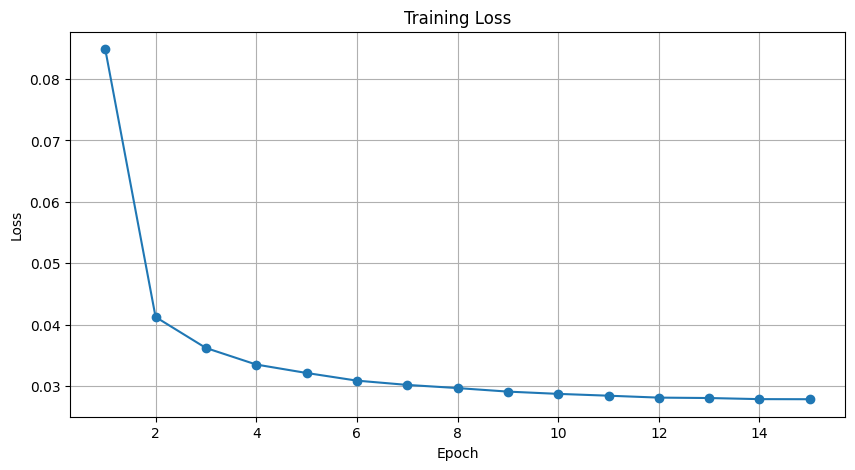

In [5]:
def train_ar_model(model, train_loader, epochs=10, lr=0.001):
    """Функция обучения AR-модели"""
    model = model.to(device)
    # added weight decay
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    criterion = nn.MSELoss()

    train_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        batch_count = 0

        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')

        for batch_idx, (data, _) in enumerate(progress_bar):
            data = data.to(device)
            batch_size = data.size(0)

            pixels = data.view(batch_size, -1)

            batch_loss = 0
            optimizer.zero_grad()

            generated = pixels.clone()

            # АR, 1 by 1
            for i in range(1, 784):

                context_start = max(0, i - model.context_size)
                # context = pixels[:, context_start:i]

                teacher_forcing = torch.rand(1).item() < 0.8
                if teacher_forcing:
                    context = pixels[:, context_start:i]  # Реальные пиксели
                else:
                    context = generated[:, context_start:i]  # Сгенерированные

                if context.size(1) < model.context_size:
                    padding = torch.zeros(batch_size, model.context_size - context.size(1), device=device)
                    context = torch.cat([padding, context], dim=1)

                #
                target = pixels[:, i:i+1]
                positions = torch.tensor([i] * batch_size, device=device)
                dummy_input = torch.zeros(batch_size, 1, device=device)
                predicted = model(dummy_input, positions, context)
                #
                generated[:, i:i+1] = predicted.detach()

                loss = criterion(predicted, target)
                batch_loss += loss

            batch_loss = batch_loss / 783
            batch_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += batch_loss.item()
            batch_count += 1

            progress_bar.set_postfix({'loss': batch_loss.item()})

        avg_loss = total_loss / batch_count
        train_losses.append(avg_loss)
        print(f'Epoch {epoch+1}, Average Loss: {avg_loss:.6f}')
        scheduler.step()

    return train_losses

img_size = 28
context_size = 256  #32 96 192 256
hidden_dim = 256    # 128, 256, 768

model = PixelARModel(
    img_size=img_size,
    hidden_dim=hidden_dim,
    context_size=context_size
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# print("Model architecture:")
# print(model)

epochs = 15

train_losses = train_ar_model(model, train_loader, epochs=epochs, lr=0.0003)

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

In [ ]:
# Model parameters: 3,554,305
# Epoch 1/15: 100%|██████████| 469/469 [08:10<00:00,  1.05s/it, loss=0.0314]
# Epoch 1, Average Loss: 0.067037
# Epoch 2/15: 100%|██████████| 469/469 [08:06<00:00,  1.04s/it, loss=0.0256]
# Epoch 2, Average Loss: 0.028114
# ...
# Epoch 12/15: 100%|██████████| 469/469 [08:08<00:00,  1.04s/it, loss=0.019]
# Epoch 12, Average Loss: 0.019213
# Epoch 13/15: 100%|██████████| 469/469 [08:07<00:00,  1.04s/it, loss=0.0201]
# Epoch 13, Average Loss: 0.019020
# Epoch 14/15:  16%|█▌        | 73/469 [01:15<06:40,  1.01s/it, loss=0.0195]

In [6]:
def generate_image(model, seed=None, img_size=28, device='cuda', t=0.2):
    """Генерация изображения с помощью AR-модели"""
    model.eval()
    total_pixels = img_size * img_size

    # Начальное изображение (можно задать seed или начать с нулей)
    if seed is not None:
        torch.manual_seed(seed)

    # Начинаем с случайного первого пикселя
    generated = torch.zeros(1, total_pixels, device=device)
    generated[0, 0] = torch.randn(1, device=device) * 0.5

    with torch.no_grad():
        for i in range(1, total_pixels):
            # Контекст: предыдущие пиксели
            context_start = max(0, i - model.context_size)
            context = generated[:, context_start:i]

            # Дополняем контекст до нужного размера, если необходимо
            if context.size(1) < model.context_size:
                padding = torch.zeros(1, model.context_size - context.size(1), device=device)
                context = torch.cat([padding, context], dim=1)

            # Позиция
            positions = torch.tensor([i], device=device)

            # Предсказываем следующий пиксель
            # Используем нулевой вход для текущего пикселя (так как он еще не сгенерирован)
            dummy_input = torch.zeros(1, 1, device=device)
            next_pixel = model(dummy_input, positions, context)

            # Добавляем небольшой шум для разнообразия
            # noise = torch.randn_like(next_pixel) * 0.1
            noise = torch.randn_like(next_pixel) * t * 0.1
            generated[0, i] = next_pixel + noise

    # Преобразуем в изображение
    generated_image = generated.view(1, 1, img_size, img_size)

    return generated_image

def generate_with_condition(model, condition_pixels=100, img_size=28, device='cuda'):
    """Генерация с частичным условием (первые N пикселей из реального изображения)"""
    model.eval()
    device = next(model.parameters()).device
    total_pixels = img_size * img_size

    # Берем реальное изображение из тестового набора
    test_image, label = test_dataset[0]
    test_pixels = test_image.view(-1).to(device)

    # Создаем изображение для генерации
    generated = torch.zeros(1, total_pixels, device=device)

    # Используем первые condition_pixels пикселей из реального изображения
    generated[0, :condition_pixels] = test_pixels[:condition_pixels]

    with torch.no_grad():
        for i in range(condition_pixels, total_pixels):
            context_start = max(0, i - model.context_size)
            context = generated[:, context_start:i]

            if context.size(1) < model.context_size:
                padding = torch.zeros(1, model.context_size - context.size(1), device=device)
                context = torch.cat([padding, context], dim=1)

            positions = torch.tensor([i], device=device)
            dummy_input = torch.zeros(1, 1, device=device)
            next_pixel = model(dummy_input, positions, context)

            # Меньше шума для более детерминированной генерации
            noise = torch.randn_like(next_pixel) * 0.05
            generated[0, i] = next_pixel + noise

    generated_image = generated.view(1, 1, img_size, img_size)

    return generated_image, test_image

def denormalize_image(img_tensor):
    """Денормализация изображения из диапазона [-1, 1] в [0, 1]"""
    return (img_tensor + 1) / 2

generation:


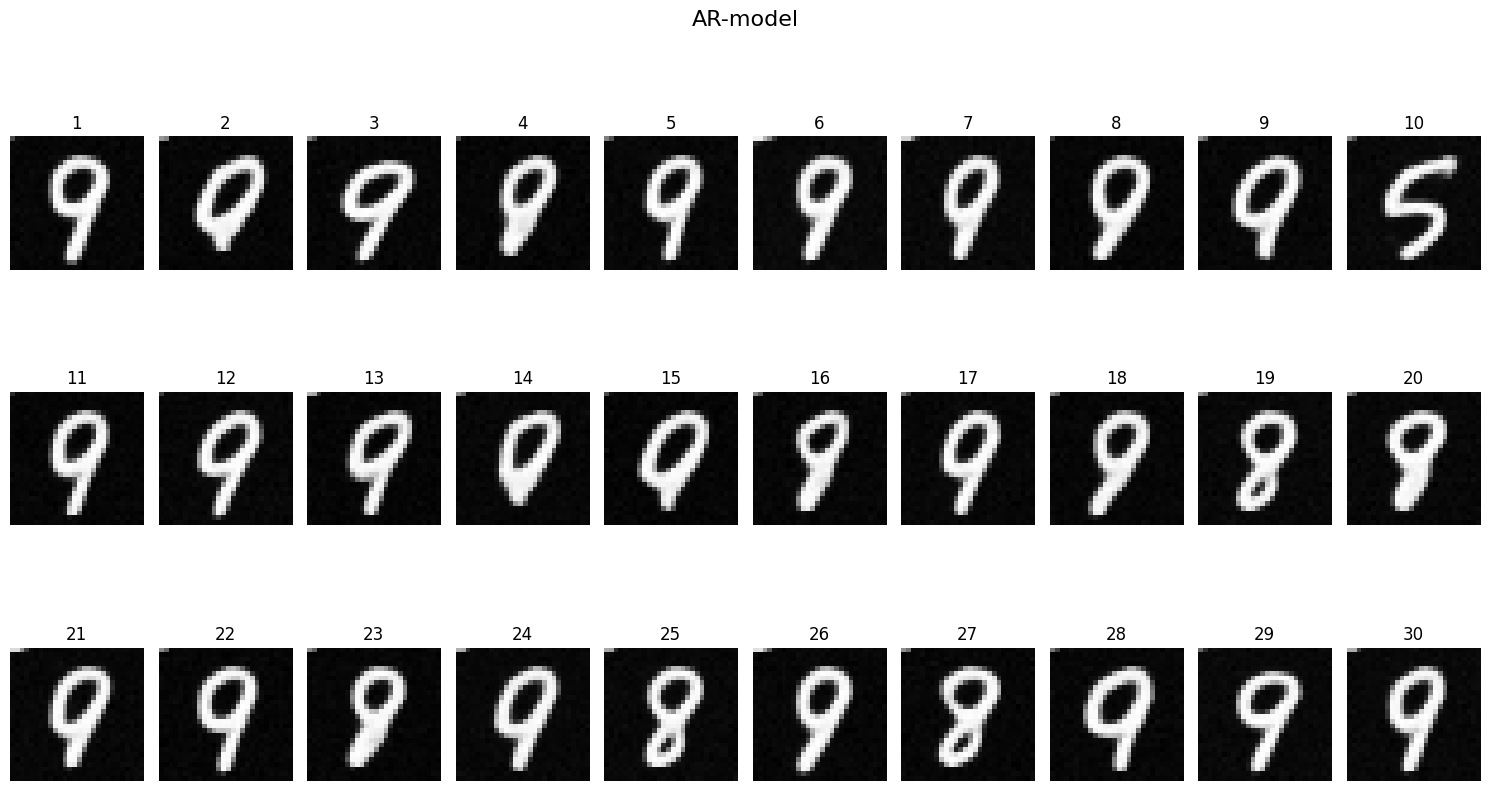

In [42]:
num_generations = 30
generated_images = []

print("generation:")
for i in range(num_generations):
    generated = generate_image(model, seed=i*5, img_size=28, device=device)
    generated_images.append(generated)
    # print(f"img {i+1}")

rows = 3
cols = 10
fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
fig.suptitle('AR-model', fontsize=16)

for i, ax in enumerate(axes.flatten()):
    img = generated_images[i].cpu().squeeze().numpy()
    img = denormalize_image(img)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()


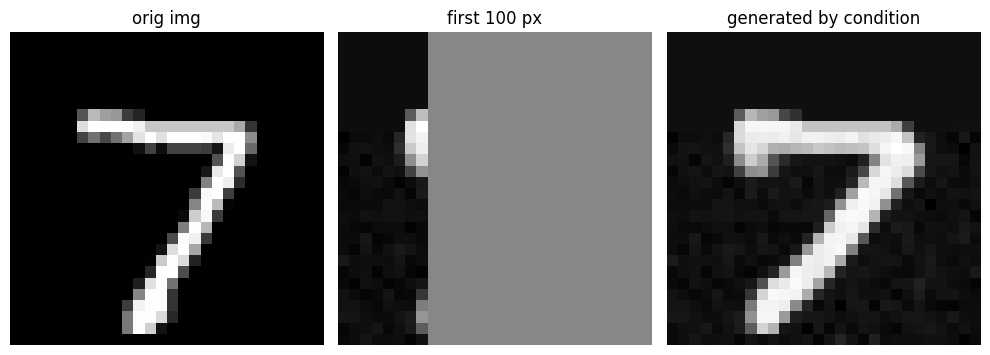

In [39]:
# Генерация с условием (частичное заполнение)
# print("\nГенерация с частичным условием (первые 100 пикселей из реального изображения):")
condition_pixels=250
conditioned_image, original_image = generate_with_condition(model, condition_pixels=condition_pixels)

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

# Оригинальное изображение
orig_img = original_image.squeeze().numpy()
orig_img = denormalize_image(orig_img)
axes[0].imshow(orig_img, cmap='gray')
axes[0].set_title('orig img')
axes[0].axis('off')

# Частично заполненное (первые 100 пикселей)
partial_img = torch.zeros_like(conditioned_image)
partial_img[0, 0, :, :condition_pixels//28] = conditioned_image[0, 0, :, :condition_pixels//28]
partial_img = partial_img.cpu().squeeze().numpy()
partial_img = denormalize_image(partial_img)
axes[1].imshow(partial_img, cmap='gray')
axes[1].set_title('first 100 px')
axes[1].axis('off')

# Полностью сгенерированное
gen_img = conditioned_image.cpu().squeeze().numpy()
gen_img = denormalize_image(gen_img)
axes[2].imshow(gen_img, cmap='gray')
axes[2].set_title('generated by condition')
axes[2].axis('off')

plt.tight_layout()
plt.show()

generation:
img 1
img 2
img 3
img 4
img 5


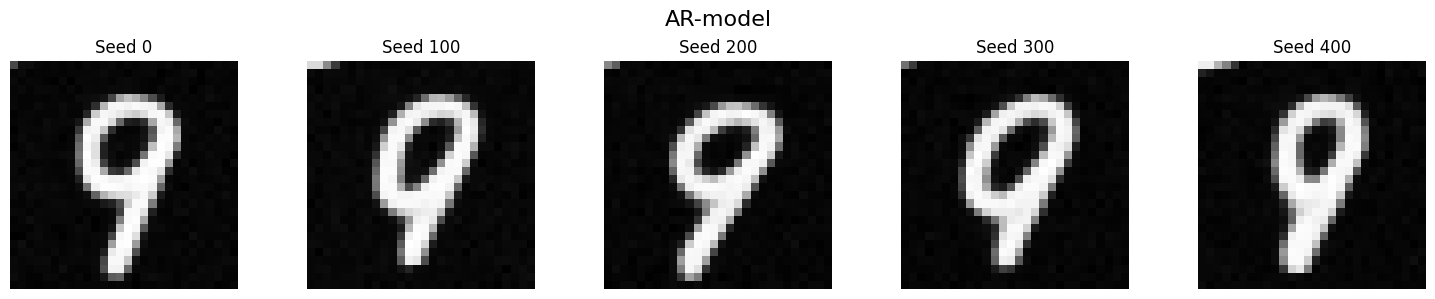

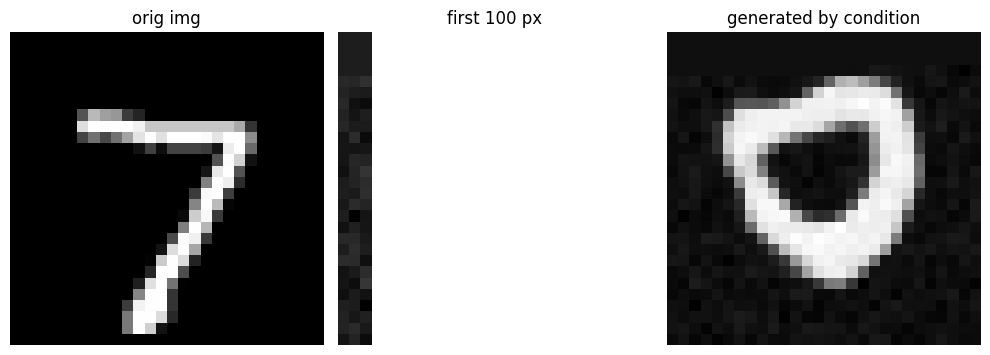

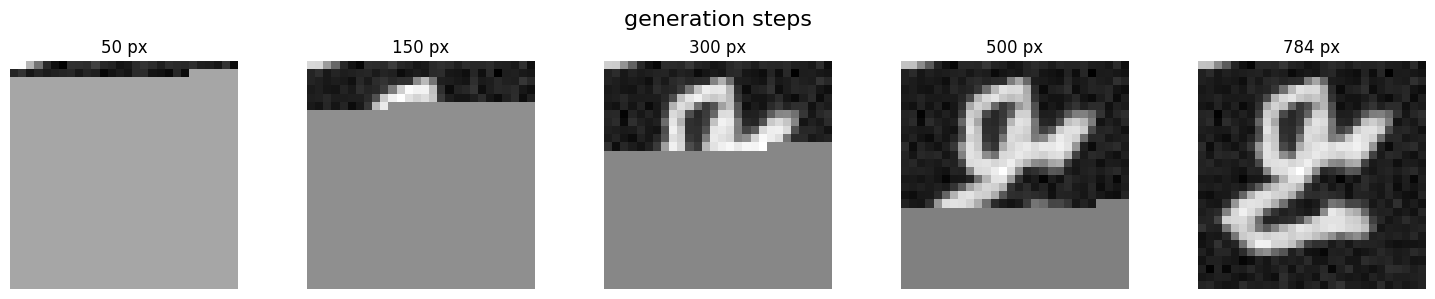

In [7]:
# Генерируем несколько изображений
num_generations = 5
generated_images = []

print("generation:")
for i in range(num_generations):
    generated = generate_image(model, seed=i*100, img_size=28, device=device)
    generated_images.append(generated)
    print(f"img {i+1}")

# Визуализация сгенерированных изображений
fig, axes = plt.subplots(1, num_generations, figsize=(15, 3))
fig.suptitle('AR-model', fontsize=16)

for i, ax in enumerate(axes):
    img = generated_images[i].cpu().squeeze().numpy()
    img = denormalize_image(img)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Seed {i*100}')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Генерация с условием (частичное заполнение)
# print("\nГенерация с частичным условием (первые 100 пикселей из реального изображения):")
conditioned_image, original_image = generate_with_condition(model, condition_pixels=100)

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

# Оригинальное изображение
orig_img = original_image.squeeze().numpy()
orig_img = denormalize_image(orig_img)
axes[0].imshow(orig_img, cmap='gray')
axes[0].set_title('orig img')
axes[0].axis('off')

# Частично заполненное (первые 100 пикселей)
partial_img = torch.zeros_like(conditioned_image)
partial_img[0, 0, :, :100//28] = conditioned_image[0, 0, :, :100//28]
partial_img = partial_img.cpu().squeeze().numpy()
partial_img = denormalize_image(partial_img)
axes[1].imshow(partial_img, cmap='gray')
axes[1].set_title('first 100 px')
axes[1].axis('off')

# Полностью сгенерированное
gen_img = conditioned_image.cpu().squeeze().numpy()
gen_img = denormalize_image(gen_img)
axes[2].imshow(gen_img, cmap='gray')
axes[2].set_title('generated by condition')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Последовательность генерации (анимация процесса)
def generate_step_by_step(model, steps=[50, 100, 200, 400, 784], seed=42):
    """Генерация изображения по шагам"""
    model.eval()
    total_pixels = 28 * 28

    torch.manual_seed(seed)
    generated = torch.zeros(1, total_pixels, device=device)
    generated[0, 0] = torch.randn(1, device=device) * 0.5

    results = []
    current_step = 0

    with torch.no_grad():
        for i in range(1, total_pixels):
            context_start = max(0, i - model.context_size)
            context = generated[:, context_start:i]

            if context.size(1) < model.context_size:
                padding = torch.zeros(1, model.context_size - context.size(1), device=device)
                context = torch.cat([padding, context], dim=1)

            positions = torch.tensor([i], device=device)
            dummy_input = torch.zeros(1, 1, device=device)
            next_pixel = model(dummy_input, positions, context)

            noise = torch.randn_like(next_pixel) * 0.1
            generated[0, i] = next_pixel + noise

            # Сохраняем промежуточные результаты
            if i + 1 in steps:
                img = generated.view(1, 1, 28, 28).cpu().squeeze().numpy()
                img = denormalize_image(img)
                results.append((steps[current_step], img))
                current_step += 1

    return results

# Получаем промежуточные результаты
intermediate_results = generate_step_by_step(model, steps=[50, 150, 300, 500, 784], seed=123)

# Визуализируем процесс генерации
fig, axes = plt.subplots(1, len(intermediate_results), figsize=(15, 3))
fig.suptitle('generation steps', fontsize=16)

for idx, (ax, (step, img)) in enumerate(zip(axes, intermediate_results)):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{step} px')
    ax.axis('off')

plt.tight_layout()
plt.show()

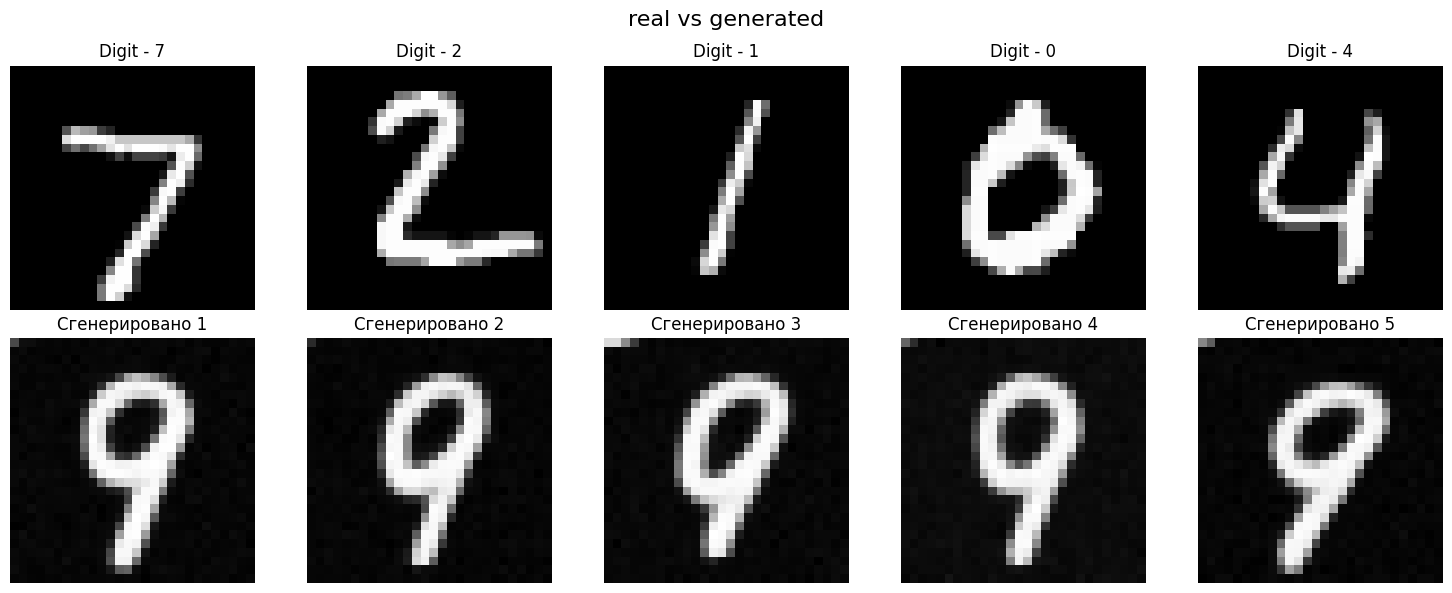

In [8]:
# Сравнение с реальными изображениями
# print("Сравнение с реальными изображениями из тестового набора:")

# Берем несколько реальных изображений
real_images = []
real_labels = []

for i in range(5):
    img, label = test_dataset[i]
    real_images.append(img)
    real_labels.append(label)

# Генерируем изображения
gen_images = []
for i in range(5):
    gen = generate_image(model, seed=i*50, img_size=28, device=device)
    gen_images.append(gen.cpu())

# Визуализация сравнения
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('real vs generated', fontsize=16)

for i in range(5):
    # Реальные изображения
    real_img = real_images[i].squeeze().numpy()
    real_img = denormalize_image(real_img)
    axes[0, i].imshow(real_img, cmap='gray')
    axes[0, i].set_title(f'Digit - {real_labels[i]}')
    axes[0, i].axis('off')

    # Сгенерированные изображения
    gen_img = gen_images[i].squeeze().numpy()
    gen_img = denormalize_image(gen_img)
    axes[1, i].imshow(gen_img, cmap='gray')
    axes[1, i].set_title(f'Сгенерировано {i+1}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:

print("\nАнализ:")
print("1. AR-модель научилась генерировать структуры, похожие на цифры")
print("2. Качество зависит от размера контекста и сложности модели")
print("3. Для улучшения результатов можно:")
print("   - Увеличить размер модели и контекста")
print("   - Обучать большее количество эпох")
print("   - Использовать более сложные архитектуры (трансформеры)")
print("   - Применить технику teacher forcing при обучении")


Анализ:
1. AR-модель научилась генерировать структуры, похожие на цифры
2. Качество зависит от размера контекста и сложности модели
3. Для улучшения результатов можно:
   - Увеличить размер модели и контекста
   - Обучать большее количество эпох
   - Использовать более сложные архитектуры (трансформеры)
   - Применить технику teacher forcing при обучении
